# Part1

- Exploração dos Dados

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import re
import numpy as np
import spacy 
from collections import Counter

In [38]:
nlp = spacy.load("pt_core_news_sm")

In [39]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

numpy     : 2.2.6
re        : 2.2.1
wordcloud : 1.9.4
pandas    : 2.2.3
matplotlib: 3.10.6
spacy     : 3.8.7
seaborn   : 0.13.2



In [40]:
sns.set_theme(style="white")
cmap = sns.color_palette("Blues", as_cmap=True)

In [41]:
df = pd.read_excel('C:/Users/03828092/Desktop/EBAP/EBAP_2025.xlsx')

In [42]:
df.head(20)

,Horario,Titulo_Autores,Modalidade,Area_tematica
0,13:00 - 13:10,(1062898) Os cursos do Campo de Públicas e sua...,Artigo,"GT01 - Ensino, pesquisa e extensão no Campo de..."
1,13:10 - 13:20,(1062725) Especialista em Políticas Públicas e...,Artigo,"GT01 - Ensino, pesquisa e extensão no Campo de..."
2,13:20 - 13:30,(1063443) Formação por competências no Campo d...,Artigo,"GT01 - Ensino, pesquisa e extensão no Campo de..."
3,14:30 - 14:40,(1063126) EDUCAÇÃO FISCAL NAS ESCOLAS PÚBLICAS...,Relato Técnico,"GT01 - Ensino, pesquisa e extensão no Campo de..."
4,14:40 - 14:50,(1062922) A curricularização da extensão do cu...,Caso de Ensino,"GT01 - Ensino, pesquisa e extensão no Campo de..."
5,14:50 - 15:00,(1063398) Entre a técnica e o saber prático: d...,Artigo,"GT01 - Ensino, pesquisa e extensão no Campo de..."
6,15:00 - 15:10,(1063222) A qualificação do servidor e o forta...,Relato Técnico,"GT01 - Ensino, pesquisa e extensão no Campo de..."
7,16:00 - 16:10,(1063466) A EFICÁCIA DE PRÁTICAS PEDAGÓGICAS\n...,Artigo,"GT01 - Ensino, pesquisa e extensão no Campo de..."
8,16:10 - 16:20,(1062555) A Educação Ambiental no ensino básic...,Artigo,"GT01 - Ensino, pesquisa e extensão no Campo de..."
9,13:00 - 13:10,(1063449) PAGAMENTOS DIGITAIS: O NOVO ALVO DA ...,Artigo,GT02 -\n Finanças Públicas e Accountability


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Horario         395 non-null    object
 1   Titulo_Autores  395 non-null    object
 2   Modalidade      395 non-null    object
 3   Area_tematica   395 non-null    object
dtypes: object(4)
memory usage: 12.5+ KB


In [44]:
df.head()

,Horario,Titulo_Autores,Modalidade,Area_tematica
0,13:00 - 13:10,(1062898) Os cursos do Campo de Públicas e sua...,Artigo,"GT01 - Ensino, pesquisa e extensão no Campo de..."
1,13:10 - 13:20,(1062725) Especialista em Políticas Públicas e...,Artigo,"GT01 - Ensino, pesquisa e extensão no Campo de..."
2,13:20 - 13:30,(1063443) Formação por competências no Campo d...,Artigo,"GT01 - Ensino, pesquisa e extensão no Campo de..."
3,14:30 - 14:40,(1063126) EDUCAÇÃO FISCAL NAS ESCOLAS PÚBLICAS...,Relato Técnico,"GT01 - Ensino, pesquisa e extensão no Campo de..."
4,14:40 - 14:50,(1062922) A curricularização da extensão do cu...,Caso de Ensino,"GT01 - Ensino, pesquisa e extensão no Campo de..."


In [45]:
df.tail()

,Horario,Titulo_Autores,Modalidade,Area_tematica
390,14:00 - 14:10,(1062925) PROGRAMA BOLSA FAMÍLIA: UMA CARACTER...,Artigo,GT12 -\n Implementação e Avaliação de Polític...
391,14:10 - 14:20,(1062779) Programa Auxílio Conectividade da Un...,Artigo,GT12 -\n Implementação e Avaliação de Polític...
392,14:20 - 14:30,(1063379) Predição da Evasão Escolar e Propost...,Artigo,GT12 -\n Implementação e Avaliação de Polític...
393,14:30 - 14:40,(1063273) Avaliação de implementação da políti...,Artigo,GT12 -\n Implementação e Avaliação de Polític...
394,14:40 - 14:50,(1063492) Estudo com dados em painel do Progra...,Artigo,GT12 -\n Implementação e Avaliação de Polític...


In [46]:
tabela_cruzada = pd.crosstab(df['Area_tematica'], df['Modalidade'])

# Part 2

- Gráficos

C:\Users\03828092\AppData\Local\Temp\ipykernel_20064\4100385909.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='Area_tematica', data=df, order=df['Area_tematica'].value_counts().index, palette='Blues_d')


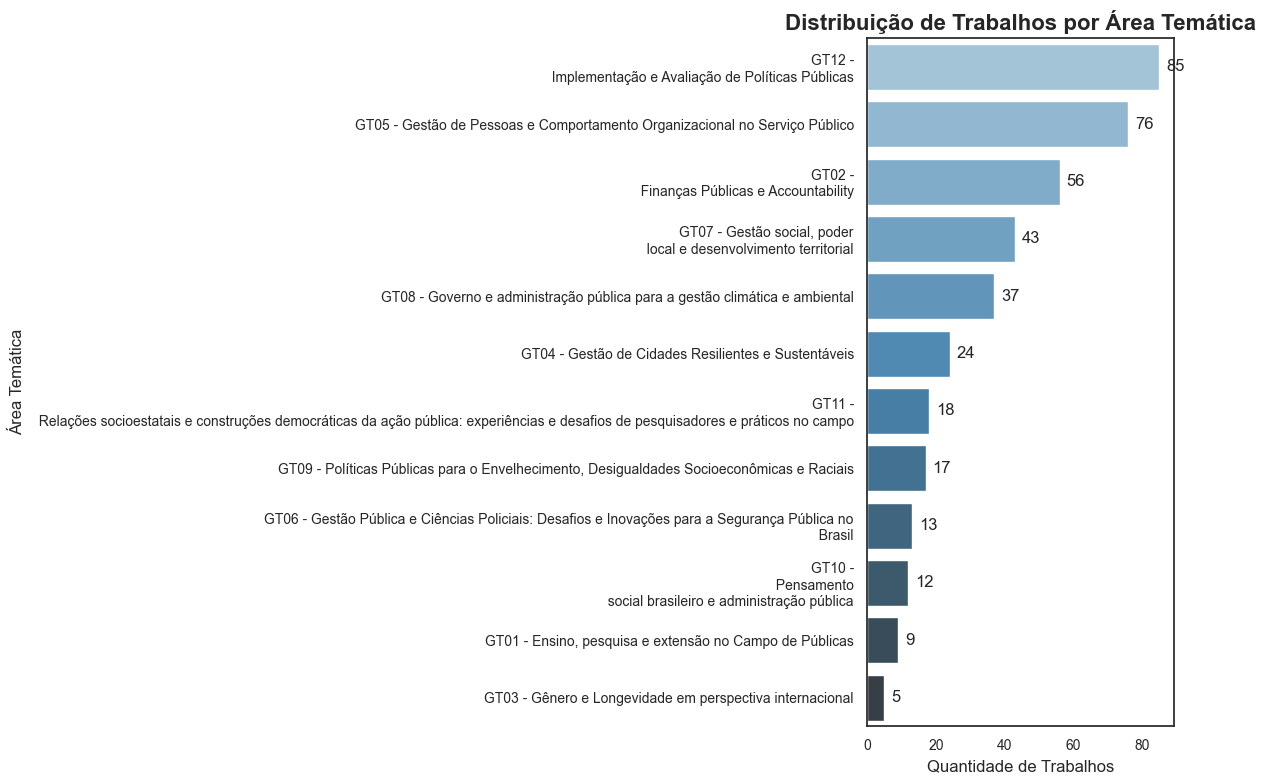

In [47]:
plt.figure(figsize=(12, 8))
ax = sns.countplot(y='Area_tematica', data=df, order=df['Area_tematica'].value_counts().index, palette='Blues_d')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5)

plt.title('Distribuição de Trabalhos por Área Temática', fontsize=16, weight='bold')
plt.xlabel('Quantidade de Trabalhos', fontsize=12)
plt.ylabel('Área Temática', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout() 
plt.show()

In [48]:
df['Modalidade'].value_counts()

Modalidade
Artigo            315
Relato Técnico     64
Caso de Ensino     16
Name: count, dtype: int64

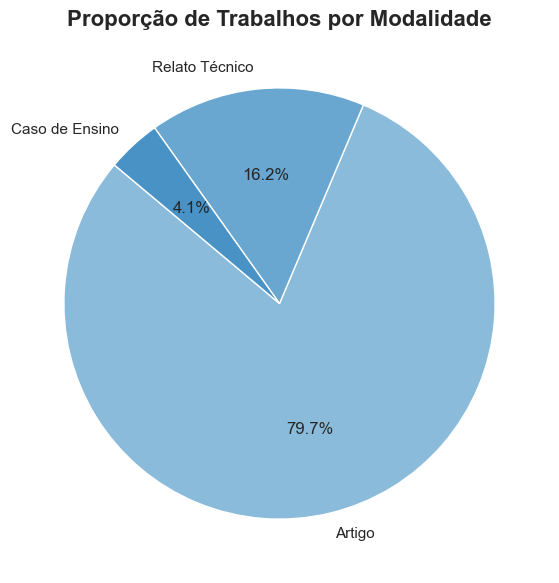

In [49]:
modalidade_counts = df['Modalidade'].value_counts()

plt.figure(figsize=(10, 7))
plt.pie(modalidade_counts, labels=modalidade_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Blues_d"))
plt.title('Proporção de Trabalhos por Modalidade', fontsize=16, weight='bold')
plt.ylabel('')
plt.show()

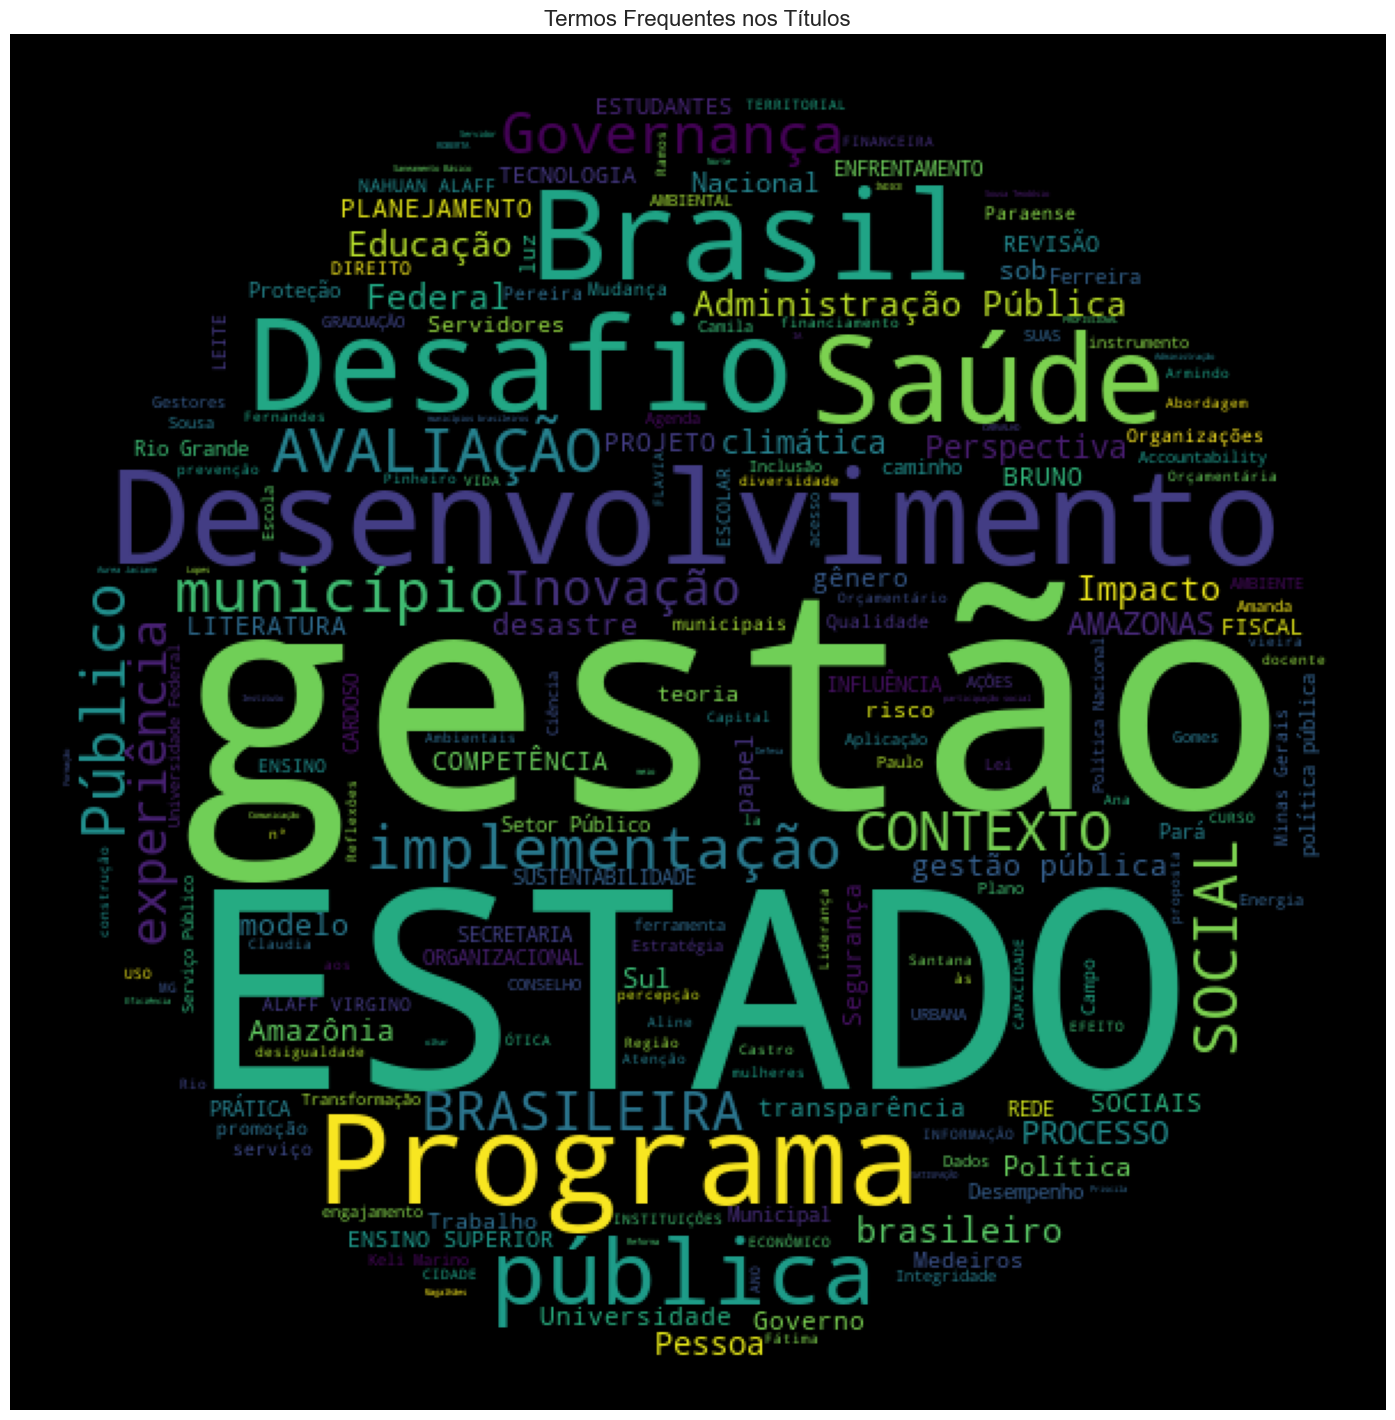

In [50]:
titulos_completos = ' '.join(df['Titulo_Autores'].dropna())
titulos_sem_codigos = re.sub(r'\(\d+\)', '', titulos_completos)

doc = nlp(titulos_sem_codigos)
tokens_sem_nomes = [token.text for token in doc if token.ent_type_ != "PER"]
titulos_sem_nomes = " ".join(tokens_sem_nomes)

stopwords = set(STOPWORDS)
custom_stopwords = {'de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'com', 'não', 'uma',
                  'os', 'no', 'na', 'por', 'mais', 'as', 'dos', 'como', 'mas', 'foi', 'ao', 'seu', 'sua',
                  'ou', 'quando', 'muito', 'se', 'já', 'eu', 'são', 'pela', 'pelas', 'este', 'esse',
                  'análise', 'estudo', 'partir', 'sobre', 'políticas', 'públicas', 'Apresentadores', 'Programa' 'Santo', 'Silva', 'das', 'Santos', 'caso'
                  'VIRGINO SOARES', 'Oliveira', 'Souza', 'CUIDADO', 'Rodrigues', 'Barbosa', 'alves', 'COSTA', 'Barros', 'CRISTIANE', 'Cristina', 'caso',
                  'à', 'nos', 'entre', 'Lima', 'SOARES', 'Rocha', 'Araujo', 'Paula', 'Keli Marino', 'Claudia Cristina', 'Ribeiro', 'MARIA', 'nas', 'cristina camila',
'rafael ferreira','caldas castro','santos sousa','renata','anderson nascimento','nahuan alaff','castro braga','sousa teodósio','rômulo keli','olimpio caldas','dayse anancio',
'josmar francisco','santo aguiar','aurea jaciane','laís silveira','socorro oliveira','rodrigues costa','carmen pineda','fernandes silva','saraiva laurinho','aline nascimento',
'crystiane amaral','bastos silva','andre araujo','camila teles','barbara silva','sousa ferreira','cristiane conceição','scarpeline castro','francisco crystello','silva paixão','silva paixão','cirhakarula muderwa'
,'sabrina olimpo','nascimento saraiva','francisco crystello','costa leite','lana montezano','moura vogt','flavia maria','cristiane socorro','fernandes silva','nahuan alaff','carmen pineda','armindo santos',
'castro braga','wander marcondes','keli marino','socorro oliveira','anderson nascimento','rafael ferreira','camila moura','sousa teodósio','teles saldanha','soares silva','armindo santos'
,'lima sailva','sousa passador','ícaro saraiva','lana montezano','tadeu anderson','alaff virginio' }
stopwords.update(custom_stopwords)

x, y = np.ogrid[:600, :600]
mask_array = (x - 300) ** 2 + (y - 300) ** 2 > 280 ** 2
mask = 255 * mask_array.astype(int)

wordcloud = WordCloud(width=600, height=600,
                      stopwords=stopwords,
                      mask=mask).generate(titulos_sem_nomes)

plt.figure(figsize=(14, 14))
plt.imshow(wordcloud)
plt.axis("off")
plt.title('Termos Frequentes nos Títulos', fontsize=16)
plt.tight_layout(pad=0)
plt.show()

tokens_finais = [word.lower() for word in titulos_sem_nomes.split() if word.lower() not in stopwords and len(word) > 2]

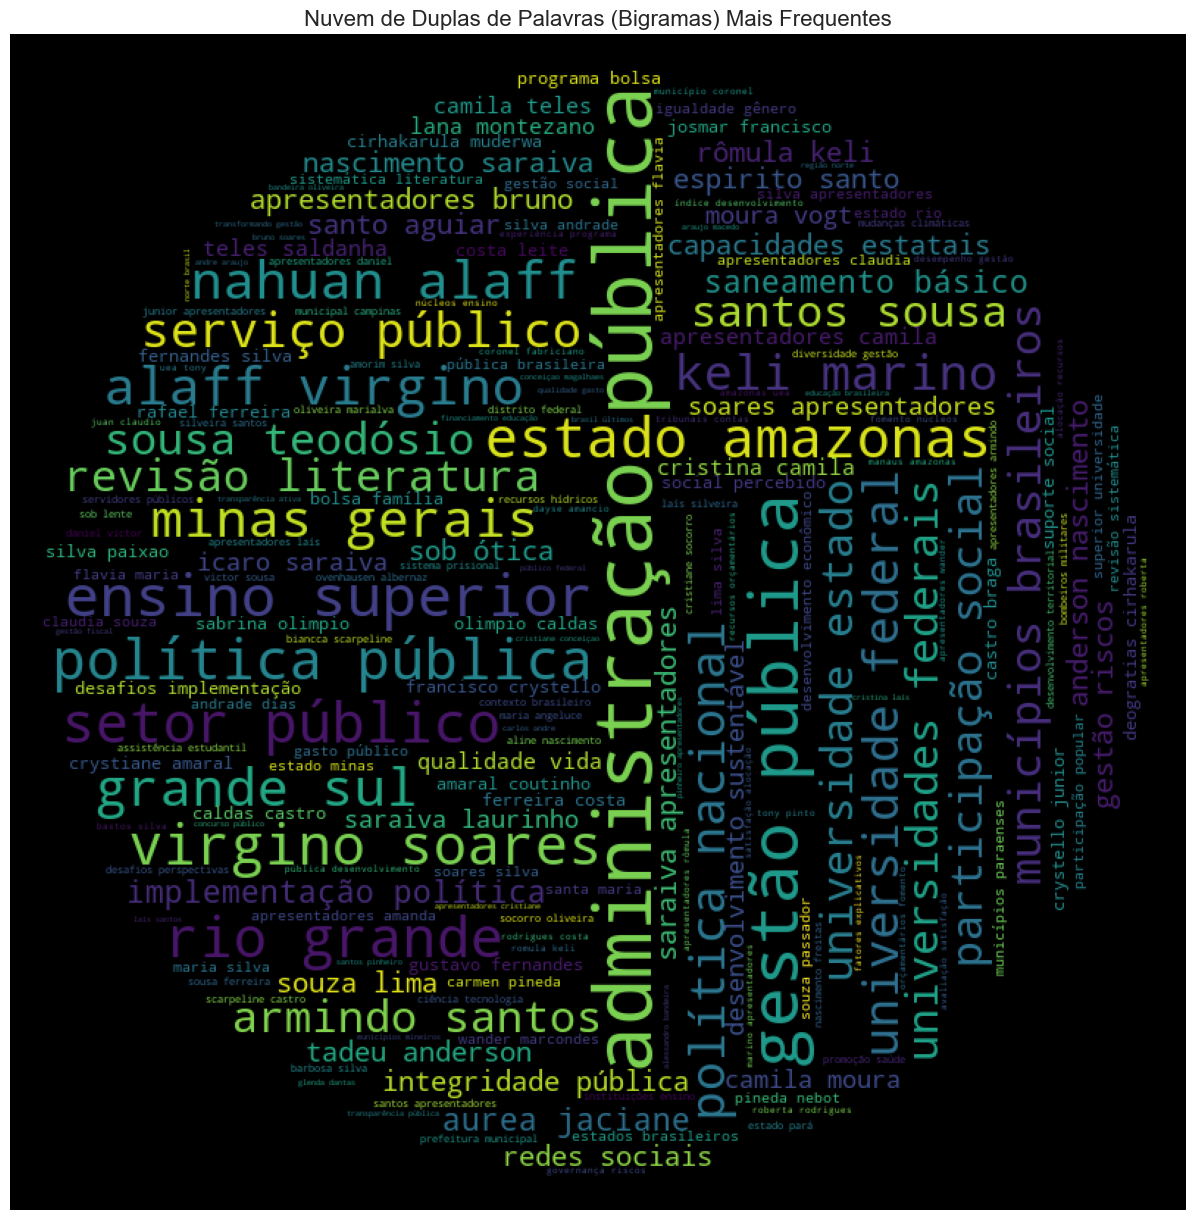

In [51]:
bigramas = zip(tokens_finais, tokens_finais[1:])

bigramas_formatados = [" ".join(bigrama) for bigrama in bigramas]
frequencia_bigramas = Counter(bigramas_formatados)

x, y = np.ogrid[:800, :800]
mask_array = (x - 400) ** 2 + (y - 400) ** 2 > 380 ** 2
mask = 255 * mask_array.astype(int)

wordcloud = WordCloud(
    width=800,
    height=800,
    mask=mask
).generate_from_frequencies(frequencia_bigramas)

plt.figure(figsize=(12, 12))
plt.imshow(wordcloud)
plt.axis("off")
plt.title('Nuvem de Duplas de Palavras (Bigramas) Mais Frequentes', fontsize=16)
plt.tight_layout(pad=0)
plt.show()

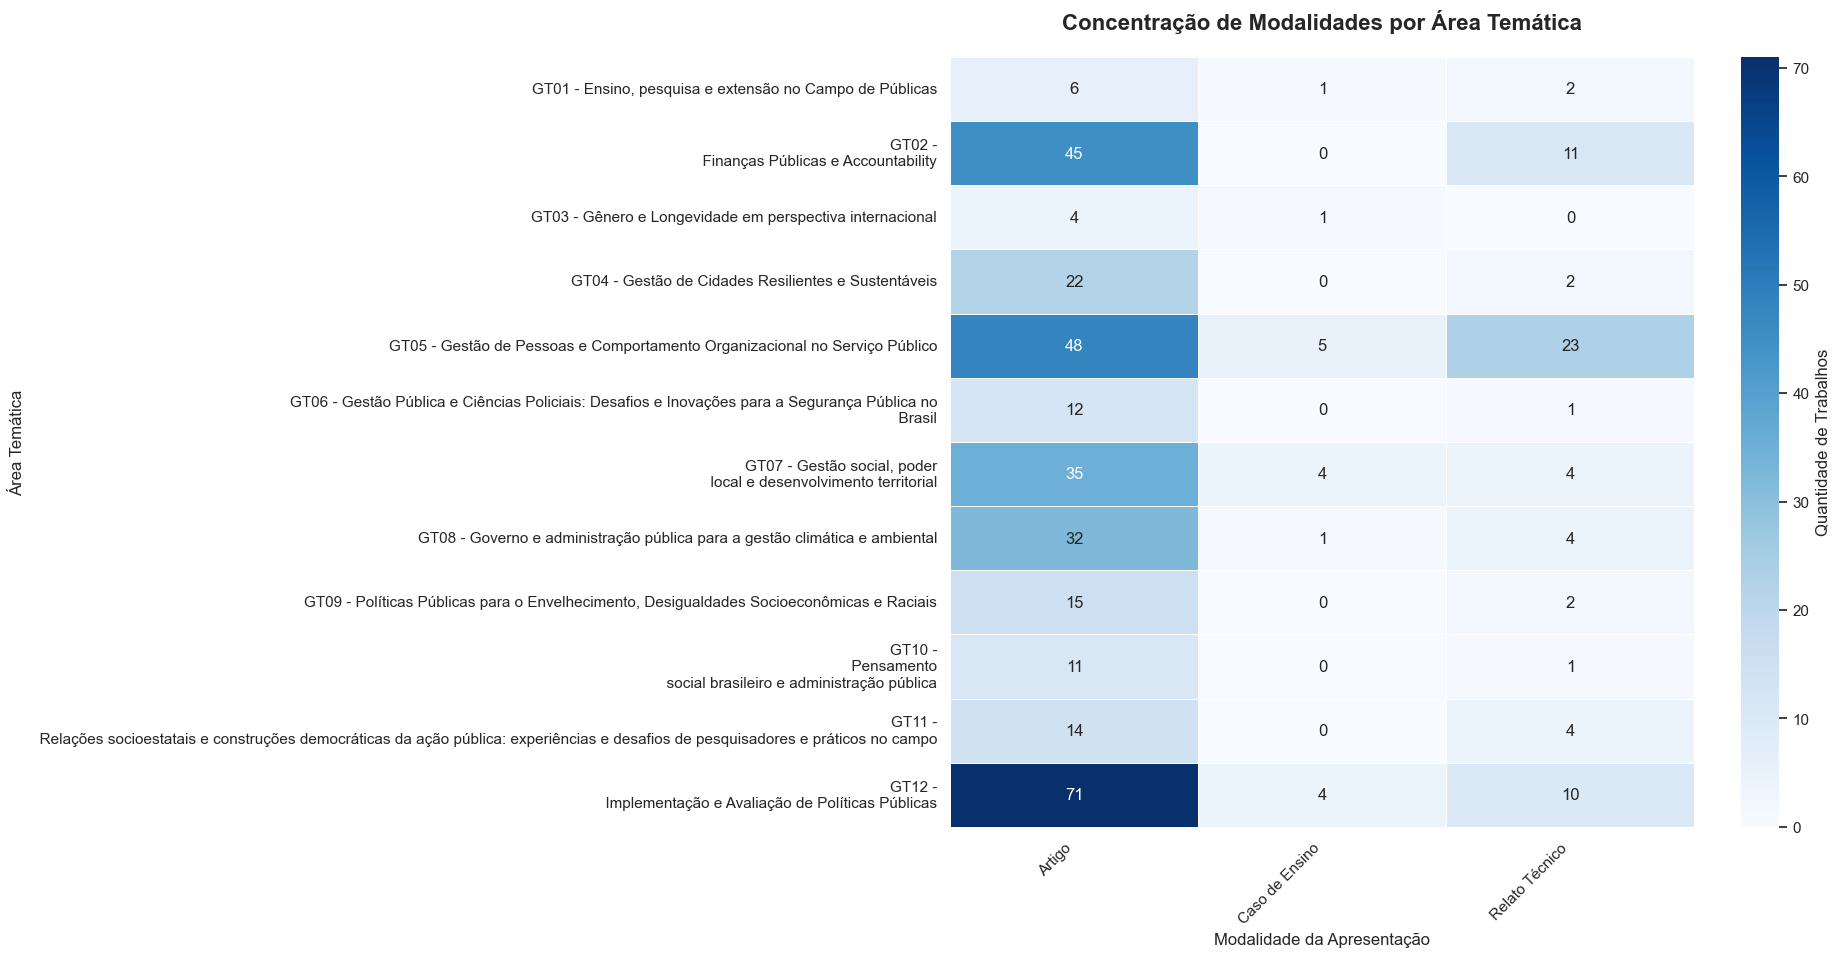

In [57]:
plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    tabela_cruzada,
    annot=True,  
    fmt="d",    
    cmap=cmap,       
    linewidths=.5,  
    cbar_kws={'label': 'Quantidade de Trabalhos'}
)

ax.set_title('Concentração de Modalidades por Área Temática', fontsize=16, weight='bold', pad=20)
ax.set_xlabel('Modalidade da Apresentação', fontsize=12)
ax.set_ylabel('Área Temática', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()
